In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVR
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error,
)

In [4]:
housing = fetch_california_housing()
X=housing.data
y=housing.target
print(housing.feature_names)
print(housing.target[:10])

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
[4.526 3.585 3.521 3.413 3.422 2.697 2.992 2.414 2.267 2.611]


In [11]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
fit_transform=scaler.fit(X_train)
X_train_scaled=fit_transform.transform(X_train)
X_test_scaled=fit_transform.transform(X_test)
svr_model=SVR(kernel='rbf',C=10,epsilon=0.1,gamma=0.1)

In [14]:
svr_model.fit(X_train_scaled,y_train)
y_pred=svr_model.predict(X_test_scaled)

In [20]:
mae=mean_absolute_error(y_test,y_pred)
print("MAE:",mae)
mse=mean_squared_error(y_test,y_pred)
print("MSE:",mse)
rmse=np.sqrt(mse)
print("RMSE:",rmse)
r2=r2_score(y_test,y_pred)
print("R2:",r2)
mape=mean_absolute_percentage_error(y_test,y_pred)
print("MAPE:",mape)

MAE: 0.38315824232651224
MSE: 0.33138717447397514
RMSE: 0.5756623788940659
R2: 0.7471116422608527
MAPE: 0.20837707703075864


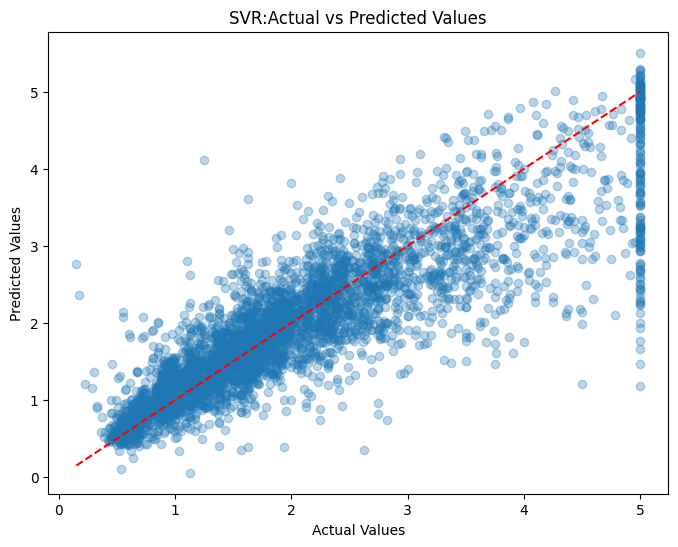

In [21]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred,alpha=0.3)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('SVR:Actual vs Predicted Values')
plt.show()